# 📘 Tutorial 3: Building the Full Bayesian Optimisation Loop in BoTorch

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Tutorial 2**, we learned how a fitted Gaussian Process surrogate can be turned into a **decision rule** through standard acquisition functions in BoTorch.

We saw that, once a surrogate is available, we can:

- define acquisition functions such as **UCB**, **PI**, and **LogEI**,
- evaluate them across the search domain,
- optimise them numerically with `optimize_acqf`,
- and interpret the candidate points they recommend.

In this tutorial, we take the next conceptual step:

> **what happens when that surrogate–acquisition–update cycle is repeated over multiple iterations?**

That is where **Bayesian Optimisation** becomes a full sequential algorithm.

This is a major shift.

In the previous tutorial, the focus was on **one acquisition step at a time**.
Here, we move to the complete optimisation workflow in which the surrogate is repeatedly updated as new data are collected.

A Bayesian Optimisation loop is not just:

- a Gaussian Process,
- plus an acquisition function,
- plus one candidate point.

It is a **sequential learning-and-decision process**.

At each step, the algorithm:

1. fits a surrogate model to the currently observed data,
2. constructs an acquisition function from that surrogate,
3. chooses the next evaluation point,
4. evaluates the objective there,
5. updates the dataset,
6. and repeats.

Once this is understood, Bayesian Optimisation becomes more than a collection of separate modelling components.

It becomes a process of:

- learning from limited observations,
- deciding what information is most valuable next,
- and gradually refining both the surrogate and the best observed solution over time.

To make this concrete, we begin with a **one-dimensional objective** so that the full BO loop remains fully interpretable through:

- evolving surrogate plots,
- selected candidate points,
- and best-observed-value curves.

We then extend the same BO logic to a **two-dimensional input space**, showing that the workflow generalises naturally beyond 1D even though the geometry becomes richer and the behaviour becomes less visually obvious.

---

**This tutorial is designed to shift perspective**
- from *“I can run one acquisition step in BoTorch”*
- to *“I can build and interpret the full sequential Bayesian Optimisation loop.”*

---

**The emphasis is on developing intuition for**
- how a single BO step becomes a repeated optimisation procedure,
- why the surrogate must be refit at every iteration,
- how new observations reshape both the posterior mean and uncertainty,
- how best observed values evolve across BO iterations,
- and how the same BO logic extends from **1D to multidimensional input spaces**.

---

**Key ideas explored include**
- building a reusable **single BO step**,
- constructing the full **sequential BO loop**,
- storing and visualising BO history over time,
- interpreting best-value improvement across iterations,
- tracking where BO chooses to sample,
- and extending standard BO from **1D** to **2D scalar-output optimisation**.

---

This tutorial serves as the practical bridge from:

- **one-step acquisition-based decision making** in Tutorial 2,
- to **full sequential Bayesian Optimisation** as a working algorithm.

In other words:

- **Tutorial 1** taught us how to build the surrogate,
- **Tutorial 2** taught us how to choose the next point,
- and **Tutorial 3** now shows how those pieces combine into the full BO loop.

---

**Recommended prerequisites**
- Completion of **Tutorials 1–2**
- Familiarity with Gaussian Process surrogate modelling in BoTorch
- Basic understanding of acquisition functions such as **PI**, **EI / LogEI**, and **UCB**
- Comfort with one-dimensional and two-dimensional visualisation of optimisation behaviour

---

**Author**: Angze Li

**Last updated**: 2026-04-07

**Version**: v1.0

## 🔧 Setup

In [1]:
import torch
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.posteriors import GPyTorchPosterior
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.optim import optimize_acqf
from botorch.acquisition.analytic import (
    UpperConfidenceBound,
    LogExpectedImprovement,
    ProbabilityOfImprovement,
)

torch.set_default_dtype(torch.double)
torch.manual_seed(0)


def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

## 1. Setting up the one-dimensional BO problem

We begin with the same one-dimensional objective used in the previous tutorial, but now place it directly into the full Bayesian Optimisation setting.

This is a deliberate choice.

The goal of Tutorial 3 is **not** to introduce a new function shape, but to study what happens when the **surrogate–acquisition–update cycle is repeated over multiple iterations**.

So instead of separating the objective definition and the initial dataset into different steps, this cell sets up the whole optimisation problem in one place:

- the hidden objective function,
- the search domain,
- the initial observed data,
- and the first visualisation of what the BO loop starts from.

---

### What the code does

The function `objective_1d(x)` defines a structured one-dimensional objective with:

- multiple negative Gaussian-shaped dips,
- oscillatory components at different frequencies,
- a mild quadratic trend,
- and a tangent-based asymmetric deformation.

Together, these produce a function with:

- multiple locally attractive regions,
- nontrivial curvature,
- and enough structure that Bayesian Optimisation has to make meaningful sequential decisions rather than repeatedly sampling the same obvious point.

The code then constructs:

- `x_dense`, a dense grid over
  $$
  [-3,\;3],
  $$
- `y_dense`, the objective evaluated across that grid,
- and `bounds_1d`, the BoTorch optimisation bounds for the one-dimensional search space.

After that, it creates an initial observed dataset:

- `train_X_1d`, a small set of initial sample locations,
- and `train_Y_1d`, the corresponding noisy observations.

Finally, it plots the true hidden objective together with the initial observed points.

So this single cell defines both:

- the optimisation landscape,
- and the data from which the BO loop will begin.

---

### Why it is useful to combine these pieces here

In Tutorial 2, it made sense to separate the function definition and the observed data, because the emphasis was on understanding acquisition functions step by step.

In Tutorial 3, the emphasis is different.

The key question is now:

> **given an initial dataset, how does Bayesian Optimisation evolve over repeated iterations?**

So it is more natural to present the objective, bounds, initial observations, and first plot together as the complete starting state of the BO problem.

That makes the notebook flow more naturally:

1. define the optimisation problem,
2. inspect the initial state,
3. run the BO loop,
4. study how the surrogate and best value evolve over time.

So yes — for this tutorial, combining these ingredients into one setup cell is the better design.

---

### How to read the figure

The figure overlays:

- the **true hidden objective** as a smooth curve,
- and the **initial observed points** as scattered markers.

This immediately shows the central situation of Bayesian Optimisation:

- the full objective exists, but the algorithm does not know it everywhere,
- it only begins with a small number of noisy observations,
- and everything that follows must be driven by a surrogate model built from that limited evidence.

So this plot should be read as the **initial information state** of the BO loop.

It shows:

- what the hidden function actually looks like,
- what information the optimiser currently has access to,
- and why a surrogate model is needed in the first place.

---

### Why reusing the same objective still makes sense

Yes — this is the same one-dimensional objective as in Tutorial 2.

That is a strength, not a problem.

By reusing the function, the notebook isolates the genuinely new concept:

- not how a one-step acquisition function behaves,
- but how the **full repeated BO loop** behaves when started from an initial dataset.

So the reader can focus on the dynamics of sequential optimisation rather than spending effort adapting to a new objective shape.

---

### Key takeaway

This cell defines the one-dimensional objective, the BO search domain, the initial observed dataset, and the first visualisation of the optimisation problem.

It is best treated as one combined setup cell, because its purpose is to establish the **entire starting state** of the one-dimensional Bayesian Optimisation loop in a single view.

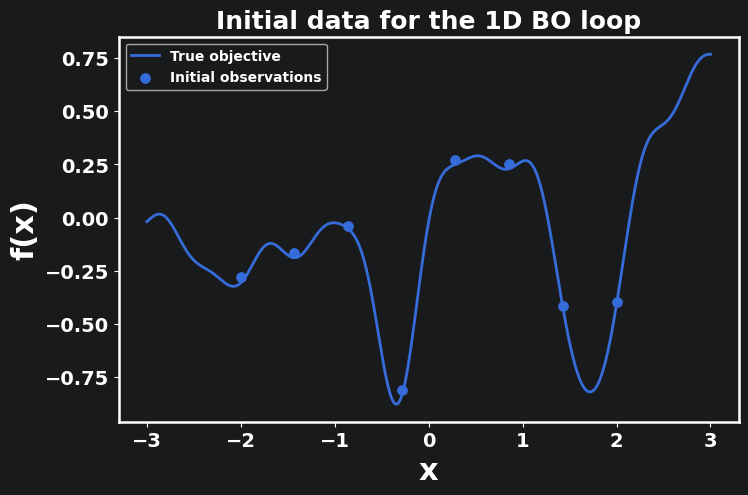

In [2]:
def objective_1d(x):
    return (
        -0.48 * torch.exp(-0.5 * ((x + 1.9) / 0.55) ** 2)
        -0.85 * torch.exp(-0.5 * ((x + 0.35) / 0.22) ** 2)
        -1.05 * torch.exp(-0.5 * ((x - 1.75) / 0.30) ** 2)
        + 0.10 * torch.sin(2.8 * x)
        + 0.06 * torch.sin(6.5 * x + 0.4)
        + 0.035 * torch.cos(11.0 * x)
        + 0.24 * torch.tan(0.3 * x)
        + 0.025 * (x - 0.4) ** 2
        + 0.16
    )

x_dense = torch.linspace(-3.0, 3.0, 500).unsqueeze(-1)
y_dense = objective_1d(x_dense)
bounds_1d = torch.tensor([[-3.0], [3.0]], dtype=torch.double)

train_X_1d = torch.linspace(-2.0, 2.0, 8).unsqueeze(-1)
train_Y_1d = objective_1d(train_X_1d) + 0.03 * torch.rand_like(train_X_1d)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="True objective")
ax.scatter(train_X_1d.numpy(), train_Y_1d.numpy(), s=45, zorder=3, label="Initial observations")
ax.set_title("Initial data for the 1D BO loop", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 2. Defining a single Bayesian Optimisation step

Before building the full BO loop, it is helpful to isolate the logic of **one acquisition–update decision step** in a reusable function.

That is exactly what `run_one_bo_step(...)` does.

This function takes the current observed dataset and performs the core Bayesian Optimisation workflow for a **single iteration**:

- fit a Gaussian Process surrogate to the current data,
- compute the posterior mean and uncertainty over the dense grid,
- define the acquisition function,
- optimise that acquisition function over the search bounds,
- and return the selected next candidate point together with the fitted surrogate information.

So this function is the atomic building block of the full BO loop that will be constructed next.

---

### What the code does

The function accepts:

- `train_X`: the currently observed input locations
- `train_Y`: the currently observed objective values
- `bounds`: the BoTorch search bounds
- `x_dense`: the dense grid used for posterior visualisation
- `beta`: an exploration parameter, included here for extensibility

The first step is:

`train_Y_bo = -train_Y`

This converts the current problem into a **maximisation-compatible form** for BoTorch acquisition functions.

Since the original objective is being treated as a **minimisation** problem, this transformation is necessary because the built-in analytic acquisition functions are typically written in a “larger is better” style.

So at this stage, the function is really fitting a GP to

$$
-f(x)
$$

rather than directly to

$$
f(x).
$$

It then computes

```python
y_best_bo = train_Y_bo.max().item()
```

which is the current best observed value in the transformed maximisation problem.

That quantity will be used by the improvement-based acquisition function.

---

### Fitting the surrogate again at every step

The code then builds and fits a fresh `SingleTaskGP`:

- using the current observed inputs `train_X`
- and the transformed outputs `train_Y_bo`

This is an important conceptual point.

The surrogate is not fit once at the beginning and then left fixed.
Instead, it is **refit at every BO step** using the data available so far.

That is one of the defining features of Bayesian Optimisation as a sequential method:

> the model changes after every new observation.

So this function represents the “current state of knowledge” at a single BO iteration.

---

### What `posterior`, `mu`, and `sigma` represent here

After fitting the GP, the function evaluates its posterior over the dense grid `x_dense` and extracts:

- `mu`: the posterior mean
- `sigma`: the posterior standard deviation

The line

```python
mu = -posterior.mean.detach()
```

converts the mean back to the **original minimisation scale**.

That is necessary because the GP was fit on the transformed targets `-train_Y`, while the later plots should remain interpretable in terms of the original objective `f(x)`.

So the quantities returned by this function are directly usable for visualisation in the original problem setting.

---

### Why `LogExpectedImprovement` is used here

The acquisition function chosen in this function is:

```python
LogExpectedImprovement(model=gp, best_f=y_best_bo)
```

This is the same **EI-style acquisition logic** that was already studied conceptually in Part 3 and implemented in Tutorial 2.

The reason `LogExpectedImprovement` is used instead of plain `ExpectedImprovement` is the same as before:

- it preserves the same improvement-based decision principle,
- but tends to be more numerically stable when the improvement is extremely small.

So this function is not introducing a new acquisition concept.
It is simply using the practical BoTorch version of EI as the default one-step rule.

---

### What `optimize_acqf(...)` is doing here

The line

```python
candidate, acq_value = optimize_acqf(...)
```

optimises the acquisition function over the allowed search bounds.

This is the moment where the posterior is turned into an actual decision.

So the selected `candidate` is the next input location that the BO algorithm would choose to evaluate under the current surrogate and acquisition rule.

The settings:

- `q=1`
- `num_restarts=10`
- `raw_samples=50`

mean that the function chooses **one** new point, using 50 initial random trial locations and 10 local optimisation restarts to improve robustness.

So this function implements a genuine one-step BO candidate selection, not just a visual scoring of the domain.

---

### Why returning a dictionary is useful

The function returns:

- the fitted BoTorch GP object `gp_bo`
- the posterior mean `mu`
- the posterior standard deviation `sigma`
- the selected candidate point
- and the acquisition value at that candidate

This is useful because a BO step has more than one important output.

We need:

- the candidate point for sequential optimisation,
- but also the posterior quantities for plotting and interpretation.

Returning all of these together makes the function a clean reusable unit for the later BO loop.

---

### Why this function is important before the full loop

This function is the bridge between:

- the **one-step acquisition workflow** built in Tutorial 2,
- and the **full repeated BO loop** that follows next.

Rather than writing the entire BO process as one large monolithic block, this notebook first isolates the single-step logic clearly.

That makes the next function, `run_bo_loop_1d(...)`, much easier to understand:

- it will simply call `run_one_bo_step(...)` repeatedly,
- add the new observation,
- and store the resulting history.

So this function is the reusable “inner loop” of Bayesian Optimisation.

---

### Key takeaway

This cell defines the reusable logic for **one Bayesian Optimisation step**.

Given the current observed data, it:

- fits a GP surrogate,
- computes the posterior mean and uncertainty,
- builds a LogEI acquisition function,
- optimises that acquisition function over the search domain,
- and returns the selected next candidate point together with the surrogate information.

So this function is the core unit that will now be repeated inside the full one-dimensional BO loop.

In [3]:
def run_one_bo_step(
    train_X,
    train_Y,
    bounds,
    x_dense
):
    train_Y_bo = -train_Y
    y_best_bo = train_Y_bo.max().item()

    gp = SingleTaskGP(
        train_X=train_X,
        train_Y=train_Y_bo,
        input_transform=Normalize(d=train_X.shape[-1]),
        outcome_transform=Standardize(m=1),
    )
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    gp.eval()

    posterior = gp.posterior(x_dense)
    mu = -posterior.mean.detach()
    var = posterior.variance.detach().clamp_min(1e-12)
    sigma = torch.sqrt(var)

    log_ei = LogExpectedImprovement(model=gp, best_f=y_best_bo)
    candidate, acq_value = optimize_acqf(
        acq_function=log_ei,
        bounds=bounds,
        q=1,
        num_restarts=10,
        raw_samples=50,
    )

    return {
        "gp_bo": gp,
        "mu": mu,
        "sigma": sigma,
        "candidate": candidate,
        "acq_value": acq_value,
    }

## 3. Defining the full one-dimensional BO loop

With the logic of a **single Bayesian Optimisation step** now isolated in `run_one_bo_step(...)`, we can build the full repeated BO procedure by applying that step sequentially.

That is exactly what `run_bo_loop_1d(...)` does.

This function starts from an initial observed dataset and then repeatedly:

- fits the current surrogate,
- selects a new candidate point through the acquisition function,
- evaluates the objective at that point,
- appends the new observation to the dataset,
- and stores the resulting state.

So this is the first place in the notebook where Bayesian Optimisation becomes a genuine **loop** rather than a one-step decision.

---

### What the code does

The function accepts:

- `train_X_init`: the initial observed input locations
- `train_Y_init`: the initial observed objective values
- `objective_fn`: the true objective function used for new evaluations
- `bounds`: the BO search bounds
- `x_dense`: the dense grid used for posterior visualisation
- `n_steps`: the number of BO update steps to perform

The first two lines clone the initial dataset:

```python
train_X = train_X_init.clone()
train_Y = train_Y_init.clone()
```

This ensures that the original inputs are preserved, while the loop works with a mutable copy of the dataset.

The list `history` is then created to store the evolving BO state over time.

---

### Why `history` is stored

At each iteration, the function appends a dictionary containing:

- the current step index
- the current observed inputs
- the current observed outputs
- the posterior mean `mu`
- the posterior standard deviation `sigma`
- and the candidate point chosen by the acquisition function

This is important because Bayesian Optimisation is a **sequential process**, and the tutorial later wants to visualise how the surrogate evolves after multiple iterations.

So `history` is not just a record of final results.
It is what makes it possible to inspect:

- the initial surrogate,
- intermediate BO states,
- and the final surrogate after several steps.

In other words, `history` stores the trajectory of the optimisation process.

---

### Why the loop uses `range(n_steps + 1)`

A subtle but important detail is the line

```python
for step in range(n_steps + 1):
```

At first glance, this may look slightly surprising, because if `n_steps = 6`, then the loop runs for:

- step 0
- step 1
- step 2
- step 3
- step 4
- step 5
- step 6

So there are **7 stored BO states**, not 6.

This is intentional.

The reason is that the function stores:

- the **initial state** before any new BO update has been applied
- plus one stored state for each later BO update

So the interpretation is:

- `n_steps = 6` means **6 BO updates / 6 newly acquired points**
- but the number of stored states is
  $$
  n_{\text{steps}} + 1
  $$
  because it includes the initial state as well

This is why, later in the notebook, the printed output correctly says:

- **Number of stored BO states (including initial state): 7**
- **Final number of observations: 14**

If the initial dataset contains 8 observations and each BO step adds 1 more point, then after 6 BO updates the final dataset contains:

$$
8 + 6 = 14
$$

So there is no discrepancy here — it is just important to distinguish between:

- **number of BO updates**
- and **number of stored states including the initial condition**

---

### How one iteration works

Inside the loop, the function calls:

`step_result = run_one_bo_step(...)`

This fits the current surrogate and selects the next candidate point under the current acquisition rule.

Then the current BO state is appended to `history`.

After that, if the loop has not yet reached the final BO step, it evaluates the objective at the selected candidate:

```python
x_new = step_result["candidate"]
y_new = objective_fn(x_new)
```

and appends the new observation to the dataset:

```python
train_X = torch.cat([train_X, x_new], dim=0)
train_Y = torch.cat([train_Y, y_new], dim=0)
```

So each BO iteration performs the standard sequential cycle:

1. build the current surrogate
2. choose the next point
3. evaluate the objective there
4. expand the dataset
5. repeat

That is the core Bayesian Optimisation loop in its simplest form.

---

### Why the update happens only when `step < n_steps`

The condition

```python
if step < n_steps:
```

ensures that the function adds a new observation only for the actual BO update steps.

This is what makes the bookkeeping consistent:

- the loop still stores the final BO state at `step = n_steps`
- but it does **not** try to add an extra point after the requested number of updates has already been completed

So the final stored state is the BO state **after the last requested update**, not before an additional unnecessary acquisition.

---

### Why this function is the real heart of the 1D tutorial

This function is where the notebook moves from:

- acquisition functions as one-step candidate selectors

to

- Bayesian Optimisation as a repeated sequential learning-and-decision process

That is the conceptual core of Tutorial 3.

The earlier tutorial showed how a surrogate can recommend one next point.
This function shows how that same logic becomes a genuine optimisation method once the acquisition-and-update step is repeated over time.

So `run_bo_loop_1d(...)` is really the first full implementation of **standard sequential BO** in the repository.

---

### Key takeaway

This function defines the full one-dimensional Bayesian Optimisation loop.

Given an initial dataset, it repeatedly:

- fits the surrogate,
- selects a new candidate point,
- evaluates the objective,
- updates the dataset,
- and stores the evolving BO state.

The parameter `n_steps` refers to the number of **BO updates**, not the number of stored states.
So when `n_steps = 6`, the function stores **7 states including the initial state**, which is exactly why the later output reports 7 stored BO states and 14 final observations.

In [4]:
def run_bo_loop_1d(
    train_X_init,
    train_Y_init,
    objective_fn,
    bounds,
    x_dense,
    n_steps=6,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()

    history = []

    for step in range(n_steps + 1):
        step_result = run_one_bo_step(
            train_X=train_X,
            train_Y=train_Y,
            bounds=bounds,
            x_dense=x_dense,
        )

        history.append({
            "step": step,
            "train_X": train_X.clone(),
            "train_Y": train_Y.clone(),
            "mu": step_result["mu"].clone(),
            "sigma": step_result["sigma"].clone(),
            "candidate": step_result["candidate"].clone(),
        })

        if step < n_steps:
            x_new = step_result["candidate"]
            y_new = objective_fn(x_new)

            train_X = torch.cat([train_X, x_new], dim=0)
            train_Y = torch.cat([train_Y, y_new], dim=0)

    return history

## 4. Running the one-dimensional BO loop

Now that the full one-dimensional BO loop has been defined, we can execute it on the initial dataset.

The call to `run_bo_loop_1d(...)` starts from:

- the initial observed inputs `train_X_1d`,
- the initial observed objective values `train_Y_1d`,
- the true objective function `objective_1d`,
- the one-dimensional search bounds `bounds_1d`,
- and the dense visualisation grid `x_dense`.

We then ask the loop to perform

- `n_steps = 6`

which means:

> run **6 Bayesian Optimisation updates** after the initial dataset.

---

### What the code does

The function call returns `history_1d`, which is the stored sequence of BO states produced by the loop.

Each entry in `history_1d` contains the surrogate and dataset state at a particular BO iteration, including:

- the currently observed inputs,
- the currently observed outputs,
- the posterior mean,
- the posterior standard deviation,
- and the candidate point selected at that stage.

So this object is the full stored trajectory of the one-dimensional BO process.

The two print statements then summarise the result:

- the total number of stored BO states
- and the final number of observations in the dataset

---

### Why the number of stored states is 7 when `n_steps = 6`

This is an important detail to interpret correctly.

The loop is storing:

- the **initial BO state**
- plus one state for each of the 6 BO updates

So the total number of stored states is:

$$
6 + 1 = 7.
$$

That is why the output reads:

- **Number of stored BO states (including initial state): 7**

This is not an off-by-one mistake.
It is simply a consequence of storing the initial state explicitly before counting the later BO-updated states.

So:

- `n_steps = 6` means **6 BO updates**
- but `len(history_1d) = 7` because the initial state is included as well

---

### Why the final number of observations is 14

The initial dataset contains 8 observations.

Then each BO update adds exactly one new point.

So after 6 BO updates, the final dataset contains:

$$
8 + 6 = 14
$$

observations.

That is why the second printed line reads:

- **Final number of observations: 14**

So again, there is no discrepancy:

- the loop performs 6 new BO evaluations,
- and the final dataset size grows from 8 to 14.

---

### Why this cell matters

This cell marks the point where the notebook moves from:

- defining the BO loop abstractly,

to

- actually running it and producing a full optimisation trajectory.

From this point onward, the tutorial can inspect how the BO process evolves over time:

- how the surrogate changes,
- where new points are selected,
- and how the best observed value improves.

So this is the execution step that makes all later visualisations possible.

---

### Key takeaway

This cell runs the full one-dimensional BO loop for 6 sequential updates and stores the resulting optimisation history in `history_1d`.

The output confirms that:

- the loop stored **7 BO states** because it includes the initial state,
- and the dataset grew to **14 observations** because 6 new BO-selected points were added to the original 8-point dataset.

In [5]:
history_1d = run_bo_loop_1d(
    train_X_init=train_X_1d,
    train_Y_init=train_Y_1d,
    objective_fn=objective_1d,
    bounds=bounds_1d,
    x_dense=x_dense,
    n_steps=6,
)

print("Number of stored BO states (including initial state):", len(history_1d))
print("Final number of observations:", history_1d[-1]["train_X"].shape[0])

Number of stored BO states (including initial state): 7
Final number of observations: 14


## 5. Visualising the evolving 1D surrogate across the BO loop

Now that the one-dimensional BO loop has been run and its full history stored, we can inspect how the surrogate changes over time.

This figure shows four snapshots of the BO process:

- the **initial surrogate**
- the surrogate **after 2 BO steps**
- the surrogate **after 4 BO steps**
- and the surrogate **after 6 BO steps**

Each panel includes:

- the **true objective**
- the GP posterior mean
- the uncertainty band
  $$
  \mu(x)\pm 2\sigma(x)
  $$
- the observed data available at that stage
- and, where applicable, the **next candidate point** selected by the acquisition function

So the figure turns the BO loop into a sequence of visually interpretable surrogate states.

---

### What the code does

The lists

- `panel_ids = [0, 2, 4, 6]`
- `panel_titles = [...]`

select four representative BO states from the stored history.

These correspond to:

- the initial condition,
- two intermediate stages,
- and the final state after 6 BO updates.

The code then loops over those stored BO states and, for each one, plots:

- the true objective `y_dense`
- the posterior mean stored in `h["mu"]`
- the uncertainty band from `h["sigma"]`
- and the current observed dataset `h["train_X"]`, `h["train_Y"]`

If the selected panel is not already the final stored state, the code also marks the **next point that the BO loop would evaluate** from that state.

So each subplot answers the question:

> **given the data observed up to this stage, what does the BO surrogate currently believe, and where would it go next?**

---

### Why this figure matters

This figure is one of the most important in the tutorial because it makes the BO loop visible as an evolving sequence rather than a single final outcome.

It shows that Bayesian Optimisation is not just:

- fitting one surrogate once,
- and then choosing one point once.

Instead, it is a repeated cycle in which:

- new observations reshape the posterior,
- uncertainty contracts in some regions,
- the surrogate mean changes as evidence accumulates,
- and the next acquisition decision depends on the current state of knowledge.

So this figure makes the **dynamic nature of BO** explicit.

---

### Explicit connection to Part 3

It is worth saying this directly:

> **in principle, this is exactly the kind of iterative visual story we already built at the end of Part 3.**

In Part 3, we manually constructed and visualised a Gaussian Process surrogate updating over repeated Bayesian Optimisation steps in one dimension.

The key conceptual ingredients were already there:

- fit the surrogate from the current data,
- evaluate an acquisition function,
- select the next point,
- add the new observation,
- and update the surrogate again.

What is different here is **not** the underlying BO logic.

What is different is that the same standard sequential process is now being implemented in **BoTorch** and organised into reusable functions and stored loop histories.

So this figure should be read as the practical BoTorch version of the iterative BO behaviour that was first developed conceptually in Part 3.

---

### How to read the panels

The panels should be compared from left to right, top to bottom.

At the **initial surrogate**, the GP has only the initial observed dataset, so uncertainty remains relatively broad in under-sampled regions.

By **after 2 BO steps**, the surrogate has already incorporated two BO-selected evaluations, so some regions become more constrained and the posterior begins to adapt.

By **after 4 BO steps**, the optimisation has accumulated enough evidence that the surrogate starts to concentrate more strongly around the more promising regions.

By **after 6 BO steps**, the posterior reflects the full one-dimensional BO trajectory run in this tutorial.

The red candidate marker in each non-final panel indicates the next action that the current surrogate–acquisition pair would take from that stage.

That is what makes the figure particularly useful:
it shows not only what the surrogate currently looks like, but also how that surrogate translates into the next BO move.

---

### Why the final panel does not show an extra “next point”

The last stored BO state already corresponds to the state **after the final requested BO update**.

So there is no additional candidate shown beyond the last requested step.

This matches the bookkeeping used earlier in the notebook:

- `n_steps = 6` means 6 BO updates,
- and `history_1d` stores the initial state plus the updated states up to that final step.

So the final panel is the endpoint of the requested BO trajectory.

---

### Why this figure is more valuable than just plotting the final surrogate

A single final surrogate plot would only show the BO outcome.

This multi-panel figure shows the **process**.

That distinction is important.

Bayesian Optimisation is a sequential decision method, so understanding it requires seeing how:

- the surrogate changes,
- the data accumulate,
- and the next-point recommendations evolve over time.

That is why this figure is much more revealing than a single end-of-loop plot.

---

### Key takeaway

This figure visualises the one-dimensional BO loop as an evolving sequence of surrogate states.

It shows how the posterior mean, uncertainty band, observed data, and next selected point change over repeated BO iterations.

And explicitly, in principle, this is the same kind of iterative BO behaviour that was already built at the end of **Part 3** — the difference is that it is now being carried out through a structured and reusable **BoTorch** implementation.

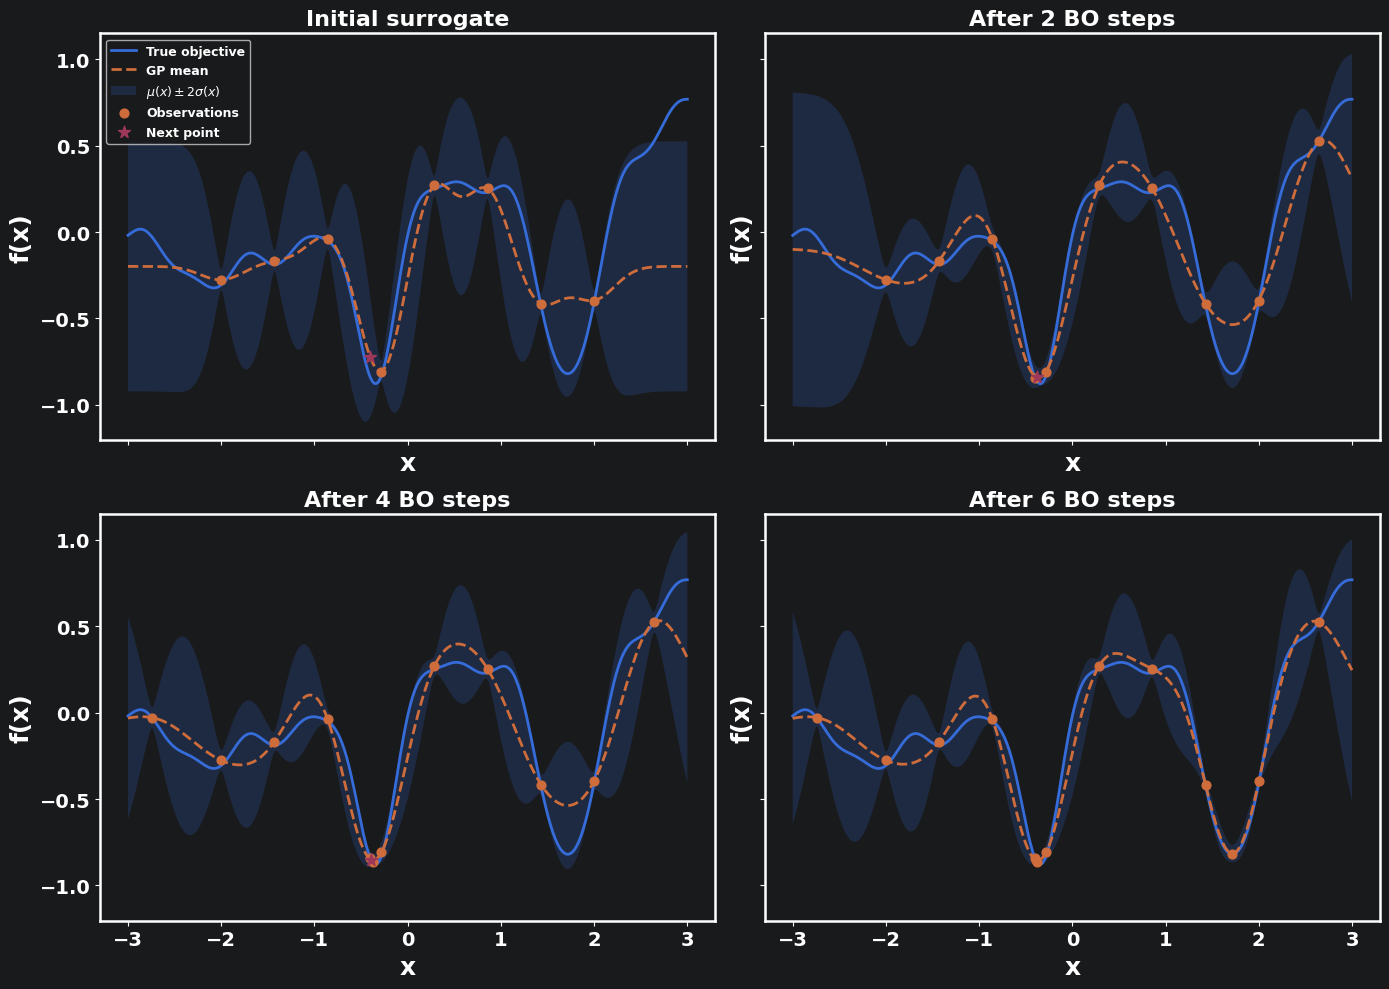

In [6]:
panel_ids = [0, 2, 4, 6]
panel_titles = [
    "Initial surrogate",
    "After 2 BO steps",
    "After 4 BO steps",
    "After 6 BO steps",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for ax, idx, title in zip(axes.flatten(), panel_ids, panel_titles):
    h = history_1d[idx]

    ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="True objective")
    ax.plot(x_dense.numpy(), h["mu"].numpy(), linewidth=2.0, linestyle="--", label="GP mean")
    ax.fill_between(
        x_dense.squeeze(-1).numpy(),
        (h["mu"] - 2.0 * h["sigma"]).squeeze(-1).numpy(),
        (h["mu"] + 2.0 * h["sigma"]).squeeze(-1).numpy(),
        alpha=0.2,
        label=r"$\mu(x)\pm 2\sigma(x)$",
    )
    ax.scatter(h["train_X"].numpy(), h["train_Y"].numpy(), s=40, zorder=3, label="Observations")

    if idx < len(history_1d) - 1:
        x_next = h["candidate"].item()
        mu_idx = torch.argmin(torch.abs(x_dense.squeeze(-1) - x_next))
        ax.scatter([x_next], [h["mu"][mu_idx].item()], s=80, marker="*", zorder=4, label="Next point")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("x", fontsize=18, fontweight="bold")
    ax.set_ylabel("f(x)", fontsize=18, fontweight="bold")
    style_ax(ax)

axes[0, 0].legend(prop={"size": 9, "weight": "bold"}, loc="upper left")
plt.tight_layout()
plt.show()

## 6. Tracking BO improvement and where the loop chooses to sample

Once the full one-dimensional BO loop has been run, there are two especially useful questions to ask:

1. **Is the best observed value improving over time?**
2. **Where in the domain is the BO loop choosing to sample?**

This figure answers both questions side by side.

The left panel tracks the best objective value found so far as the BO iterations progress.
The right panel shows the actual sequence of points chosen by the BO loop on top of the true objective.

Together, these two views provide a compact summary of how the optimisation is behaving.

---

### What the code does

The first line computes

```python
best_vals_1d = [float(torch.min(h["train_Y"])) for h in history_1d]
```

This extracts the **best observed value so far** from each stored BO state.

Because this is a minimisation problem, the best observed value at each stage is simply the minimum of the currently observed outputs.

So the sequence `best_vals_1d` records how the best value evolves as new BO-selected observations are added.

The next two lines extract the candidate points chosen by the BO loop:

- `candidate_xs` stores the x-coordinates of the BO-selected points
- `candidate_ys` evaluates the true objective at those x-values for visual placement on the true curve

It is important that `history_1d[:-1]` is used here rather than all of `history_1d`, because the final stored BO state does not have a further next point that is actually added.
So this list corresponds exactly to the points that were truly selected and evaluated during the 6 BO updates.

The code then creates a two-panel figure:

- **left panel:** best observed value vs BO iteration
- **right panel:** true objective with initial observations and BO-selected points

---

### How to read the left panel

The left panel shows the quantity

$$
\min \bigl(y_{\text{observed}}\bigr)
$$

as a function of BO iteration.

Since the objective is being minimised, lower values are better.

So this curve shows whether the BO process is actually finding better objective values over time.

A downward trend means the optimiser is successfully discovering improved observations.
Flat regions mean that some BO steps did not improve the current best value, even if they may still have been useful for reducing uncertainty or refining the surrogate.

This is an important point in Bayesian Optimisation:

> not every BO step needs to improve the best observed value immediately in order to still be useful.

Some steps are valuable because they gather information that helps later steps make better decisions.

So the left panel should be read as a compact diagnostic of optimisation progress, not as a requirement that every step must strictly improve.

---

### How to read the right panel

The right panel plots:

- the **true objective**
- the **initial observations**
- and the **points selected by the BO loop**

This makes the BO trajectory spatially visible.

Rather than only looking at best-value improvement, we can now see *where* the optimiser actually chose to sample.

This is useful because BO is not just about numerical improvement.
It is also about how the algorithm explores and exploits different regions of the domain.

The right panel therefore shows whether the loop:

- repeatedly samples near the same promising basin,
- explores multiple low-value regions,
- or spends evaluations in different parts of the domain before concentrating.

So this plot gives a complementary view to the left panel:

- the left panel tells us **how well** the BO loop is doing
- the right panel tells us **how** it is doing it

---

### Why these two panels belong together

These two plots are especially informative when shown together.

If we only looked at the best-value curve, we would know whether improvement happened, but not where the optimiser spent its budget.

If we only looked at the selected points, we would see the spatial pattern of sampling, but not whether that pattern actually improved the objective.

Together, they connect:

- **outcome**
- and **behaviour**

That makes the BO process much easier to interpret.

---

### Connection to the earlier surrogate snapshots

The earlier 2×2 surrogate figure showed how the GP posterior evolves over the BO loop.

This new figure shifts the focus slightly:

- the earlier figure emphasised the changing surrogate,
- this one emphasises the optimisation trajectory itself.

So the notebook is now building a fuller picture of Bayesian Optimisation from multiple angles:

- the evolving surrogate,
- the changing best observed value,
- and the locations of the selected points.

That is exactly the kind of multi-view understanding that makes BO easier to reason about.

---

### Key takeaway

This figure provides a compact summary of the one-dimensional BO loop from two complementary perspectives:

- the **left panel** shows how the best observed value evolves over iterations,
- and the **right panel** shows where the BO loop actually chose to sample on the objective.

Together, these plots make it easier to see not just whether the BO loop improved the objective, but also how its sequence of acquisition-driven decisions produced that improvement.

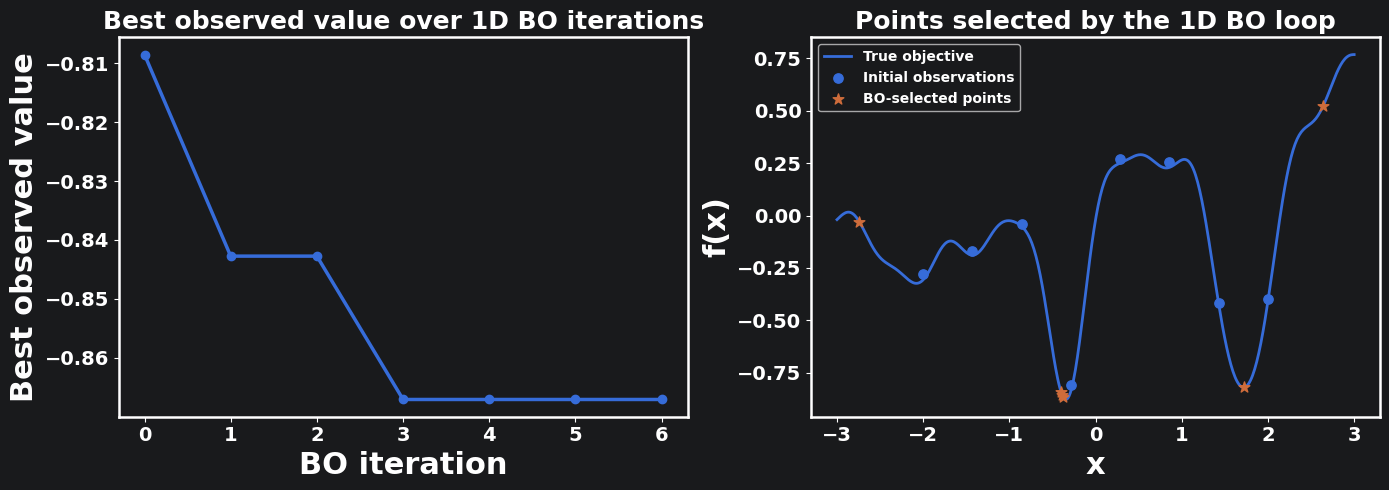

In [7]:
best_vals_1d = [float(torch.min(h["train_Y"])) for h in history_1d]

candidate_xs = [h["candidate"].item() for h in history_1d[:-1]]
candidate_ys = [objective_1d(torch.tensor([[x]], dtype=torch.double)).item() for x in candidate_xs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(len(best_vals_1d)), best_vals_1d, "-o", linewidth=2.5)
axes[0].set_title("Best observed value over 1D BO iterations", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO iteration", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Best observed value", fontsize=22, fontweight="bold")
style_ax(axes[0])

axes[1].plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="True objective")
axes[1].scatter(train_X_1d.numpy(), train_Y_1d.numpy(), s=45, zorder=3, label="Initial observations")
axes[1].scatter(candidate_xs, candidate_ys, s=65, marker="*", zorder=4, label="BO-selected points")
axes[1].set_title("Points selected by the 1D BO loop", fontsize=18, fontweight="bold")
axes[1].set_xlabel("x", fontsize=22, fontweight="bold")
axes[1].set_ylabel("f(x)", fontsize=22, fontweight="bold")
axes[1].legend(prop={"size": 10, "weight": "bold"}, loc="upper left")
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 7. Moving from one-dimensional to multidimensional Bayesian Optimisation

So far, the BO loop in this tutorial has been developed in **one dimension**.

That is the right place to begin, because in one dimension we can directly visualise:

- the true objective,
- the Gaussian Process posterior mean,
- the uncertainty band,
- and the candidate points selected over time.

But real Bayesian Optimisation problems are often not one-dimensional.

In practice, we usually want to optimise objectives that depend on **multiple input variables**:

- multiple synthesis conditions,
- several experimental settings,
- or a vector of design parameters.

So the next step is to ask:

> **does the same BO logic still work when the input is multidimensional but the output is still a single scalar objective?**

That is exactly what this cell begins to set up.

---

### The idea of multidimensional BO

In the one-dimensional case, the optimisation variable is just

$$
x \in \mathbb{R}.
$$

In the two-dimensional case, the optimisation variable becomes a vector

$$
\mathbf{x} = (x_1, x_2) \in \mathbb{R}^2.
$$

The objective is still a **scalar-valued function**:

$$
f(\mathbf{x}) = f(x_1, x_2),
$$

so we are still trying to optimise one number, but now over a **two-dimensional input space**.

This is the simplest nontrivial extension of Bayesian Optimisation beyond 1D.

It is important because it shows that the standard BO workflow:

- fit a surrogate,
- define an acquisition function,
- optimise that acquisition function,
- evaluate the true objective,
- and update the dataset,

does **not** fundamentally depend on the input being one-dimensional.

What changes is mainly the geometry of the search space and the way we visualise it.

---

### What the code does

The function `objective_2d(X)` defines a two-dimensional scalar-valued objective.

The input `X` is assumed to contain two coordinates:

- `x1 = X[..., 0]`
- `x2 = X[..., 1]`

and the returned objective combines several ingredients:

- a deep basin near one region of the plane,
- a second broader basin elsewhere,
- sinusoidal structure in both input directions,
- and a mild quadratic trend.

So this objective has:

- multiple attractive regions,
- nontrivial local structure,
- and enough variation to make the BO problem interesting in two dimensions.

The output is then reshaped with `.unsqueeze(-1)` so that it has the standard BoTorch-compatible scalar-output shape.

---

### Why the output is still scalar

Even though the input is now two-dimensional, the output is still a **single scalar objective value**.

That is why this is described as:

> **multidimensional input, scalar output**

This is the most standard setting for basic Bayesian Optimisation:

- the decision variable may have many dimensions,
- but the optimisation target is still one scalar quantity to minimise or maximise.

So the purpose of this section is not to introduce multi-output modelling.
It is simply to show that standard BO already extends naturally from:

- 1D input, scalar output

to

- 2D input, scalar output.

---

### What the grid construction is doing

The code then constructs a dense two-dimensional grid:

- `x1_grid`
- `x2_grid`

and combines them using:

```python
X1, X2 = torch.meshgrid(x1_grid, x2_grid, indexing="ij")
```

This creates a full grid of coordinates in the `(x_1, x_2)` plane.

Those grid coordinates are then stacked into

```python
X_grid_2d
```

which is a long list of 2D input locations of shape `(N, 2)`, where each row is one candidate point in the plane.

The objective is evaluated across that whole grid to produce

```python
Y_grid_2d
```

which is finally reshaped back into a 2D array so it can be plotted as a contour map.

So this code is doing the two-dimensional analogue of what `x_dense` and `y_dense` did in the 1D section:

- define the domain,
- evaluate the true objective densely,
- and prepare it for visualisation.

---

### Why the bounds are now `(2, 2)`

The line

```python
bounds_2d = torch.tensor([[-3.0, -3.0], [3.0, 3.0]], dtype=torch.double)
```

defines the BoTorch search bounds for the 2D problem.

This has shape

$$
(2, 2),
$$

because:

- the first row contains the lower bounds for both input dimensions
- the second row contains the upper bounds for both input dimensions

So here the search domain is

$$
x_1 \in [-3, 3], \qquad x_2 \in [-3, 3].
$$

This is the direct multidimensional extension of the one-dimensional `bounds_1d` used earlier.

---

### Why this section matters

This cell marks an important conceptual shift in the notebook.

Up to now, the BO loop has been kept one-dimensional for clarity and interpretability.

Now the notebook is beginning to show that the same logic can operate in a setting where:

- the input space is genuinely multidimensional,
- the geometry is more complex,
- and the visualisation changes from 1D curves to 2D contour maps.

So this is where Tutorial 3 begins to move from:

- **fully transparent 1D BO intuition**

toward

- **more realistic multidimensional BO structure**.

That makes it an important bridge between pedagogical BO examples and practical BO problems.

---

### Key takeaway

This cell defines a **two-dimensional scalar-output objective** and constructs a dense 2D grid for visualising it.

It also introduces the core idea of **multidimensional Bayesian Optimisation**:

> the BO workflow remains the same, but the search variable is now a vector rather than a single scalar.

So this section begins the transition from one-dimensional BO intuition to the more realistic case of BO over a multidimensional input space.

In [8]:
def objective_2d(X):
    x1 = X[..., 0]
    x2 = X[..., 1]
    return (
        -1.15 * torch.exp(-0.5 * ((x1 - 1.1) / 0.45) ** 2 - 0.5 * ((x2 - 1.5) / 0.55) ** 2)
        -0.55 * torch.exp(-0.5 * ((x1 + 1.2) / 0.8) ** 2 - 0.5 * ((x2 + 0.8) / 0.7) ** 2)
        +0.08 * torch.sin(2.2 * x1)
        +0.06 * torch.cos(2.8 * x2)
        +0.03 * (x1**2 + 0.8 * x2**2)
        +0.20
    ).unsqueeze(-1)

x1_grid = torch.linspace(-3.0, 3.0, 500)
x2_grid = torch.linspace(-3.0, 3.0, 500)
X1, X2 = torch.meshgrid(x1_grid, x2_grid, indexing="ij")
X_grid_2d = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=-1)
Y_grid_2d = objective_2d(X_grid_2d).reshape(500, 500)

bounds_2d = torch.tensor([[-3.0, -3.0], [3.0, 3.0]], dtype=torch.double)

## 8. Initial observations for the two-dimensional BO problem

Now that the two-dimensional objective and its contour grid have been defined, we need to specify the **initial dataset** from which the 2D BO loop will begin.

As in the one-dimensional case, Bayesian Optimisation does not start by knowing the full objective surface.
It only begins with a small number of observed points.

So this cell plays the same role for the 2D setting that the initial observation cell played earlier for the 1D setting:

- choose a small initial dataset,
- evaluate the objective there,
- and visualise what information the BO loop starts with.

---

### What the code does

The tensor `train_X_2d` defines six initial input locations in the two-dimensional search space.

Each row is one observed point of the form

$$
(x_1, x_2).
$$

So the BO loop initially knows the objective only at these six locations.

The line

```python
train_Y_2d = objective_2d(train_X_2d) + 0.03 * torch.rand_like(objective_2d(train_X_2d))
```

then evaluates the true objective at those points and adds a small perturbation to create noisy observations.

So, just as in the earlier 1D examples, the BO loop is not fitting to perfectly exact values.
It is fitting to slightly noisy data, which is a more realistic surrogate-modelling setting.

The figure then plots:

- the full two-dimensional objective as a contour map,
- and the initial observed locations as white markers with black edges.

So the cell makes the initial state of the 2D BO problem visible in one plot.

---

### Why only a small number of 2D observations are used

The point of Bayesian Optimisation is that the full objective is assumed to be expensive or limited in accessibility.

So we deliberately begin with only a **small set of initial observations**.

In two dimensions, this is especially important, because the size of the search space is already much larger than in 1D.
A few points are nowhere near enough to determine the full surface directly.

That is exactly why a surrogate model and acquisition function are needed.

So the sparse initial design is not a weakness of the example — it is part of the whole BO setting.

---

### Why noise is added again

The small perturbation added to `train_Y_2d` serves the same purpose as before:

- it avoids making the observations perfectly identical to the latent objective,
- and it makes the GP regression problem more realistic.

This matters because the surrogate is meant to infer an underlying function from imperfect data, not simply interpolate a perfectly noise-free table of values.

So even in the 2D case, the BO loop is operating in a slightly noisy observational setting.

---

### How to read the figure

The contour map shows the **true hidden objective** across the full two-dimensional domain.

The white points show the locations at which the BO loop initially has observed data.

So the figure should be read as the two-dimensional analogue of the 1D initial-data plot:

- the full surface exists,
- but the optimiser only begins with a small number of scattered observations,
- and everything that follows must be inferred from those points.

This makes the BO setting very concrete.

We can already see that the initial observations do **not** fully cover all attractive regions of the surface.
That is precisely why the BO loop must learn and decide sequentially.

---

### Why this matters for multidimensional BO

In one dimension, it is relatively easy to see visually what parts of the domain have been sampled and what parts remain uncertain.

In two dimensions, that issue becomes more serious:

- some regions may be completely unsampled,
- others may be only weakly constrained,
- and the surrogate must generalise over a much richer input geometry.

So this cell marks the point where the notebook begins to show why multidimensional BO is genuinely more demanding than the 1D case, even though the overall BO logic stays the same.

---

### Key takeaway

This cell defines the initial observed dataset for the two-dimensional BO problem and visualises those observations on top of the full hidden objective surface.

It establishes the starting information state of the 2D BO loop:

- a sparse set of noisy observations in a multidimensional search space,
- from which the surrogate model must learn and the acquisition function must choose where to sample next.

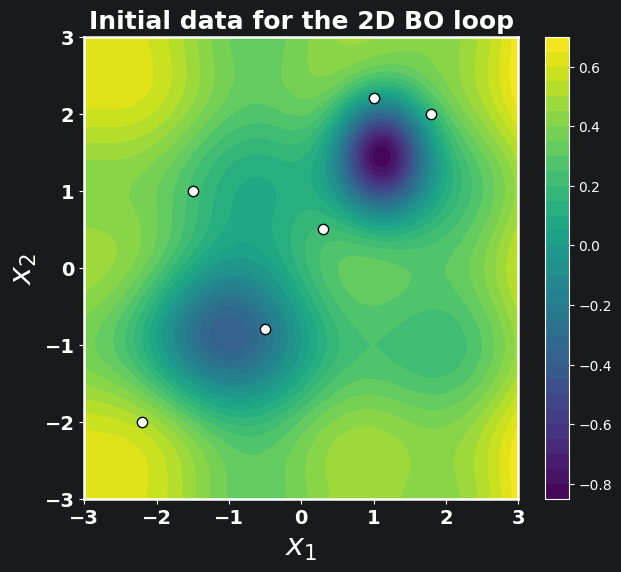

In [9]:
train_X_2d = torch.tensor(
    [
        [-2.2, -2.0],
        [-1.5,  1.0],
        [-0.5, -0.8],
        [ 0.3,  0.5],
        [ 1.0,  2.2],
        [ 1.8,  2.0],
    ],
    dtype=torch.double,
)
train_Y_2d = objective_2d(train_X_2d) + 0.03 * torch.rand_like(objective_2d(train_X_2d))

fig, ax = plt.subplots(figsize=(7, 6))
cont = ax.contourf(X1.numpy(), X2.numpy(), Y_grid_2d.numpy(), levels=30)
ax.scatter(train_X_2d[:, 0].numpy(), train_X_2d[:, 1].numpy(), s=55, color="white", edgecolors="black", zorder=3)
ax.set_title("Initial data for the 2D BO loop", fontsize=18, fontweight="bold")
ax.set_xlabel(r"$x_1$", fontsize=22, fontweight="bold")
ax.set_ylabel(r"$x_2$", fontsize=22, fontweight="bold")
style_ax(ax)
plt.colorbar(cont, ax=ax)
plt.show()

## 9. Running the full two-dimensional BO loop

With the two-dimensional objective and its initial dataset now in place, we can run the full BO loop in the same spirit as the one-dimensional case.

This is the key multidimensional extension of the tutorial:

> the BO workflow is still the same, even though the input is now a vector in $\mathbb{R}^2$ rather than a scalar in $\mathbb{R}$.

So this cell is the 2D analogue of the earlier 1D loop execution cell.
It defines the repeated 2D BO procedure, runs it from the initial 2D dataset, and reports the overall size of the resulting optimisation history.

---

### What the function does

The function `run_bo_loop_2d(...)` takes:

- `train_X_init`: the initial observed 2D input locations
- `train_Y_init`: the corresponding observed scalar objective values
- `objective_fn`: the true 2D objective function used for new evaluations
- `bounds`: the 2D BoTorch search bounds
- `n_steps`: the number of BO updates to perform

It then repeats the same essential BO cycle used in the 1D section:

1. transform the current observations into a maximisation-compatible form with
   `train_Y_bo = -train_Y`
2. fit a `SingleTaskGP` surrogate to the current data
3. define a `LogExpectedImprovement` acquisition function
4. optimise that acquisition function over the 2D search bounds
5. store the current BO state
6. if the requested number of updates has not yet been reached, evaluate the true objective at the chosen candidate and append the new observation

So, conceptually, this is exactly the same BO logic as before — only the geometry of the input space has changed.

---

### Why the code looks so similar to the 1D version

This similarity is not accidental.

In fact, one of the main messages of this section is:

> **standard Bayesian Optimisation generalises naturally from 1D to multidimensional input spaces without changing its core structure.**

The main ingredients remain unchanged:

- Gaussian Process surrogate
- improvement-based acquisition function
- optimisation of the acquisition function over the search domain
- sequential update of the dataset

What changes is mainly:

- the shape of `train_X`
- the shape of `bounds`
- the dimensionality of the acquisition optimisation problem
- and the way the results are visualised

So this function is important because it shows that multidimensional BO is not a different algorithm — it is the same BO logic operating in a richer input space.

---

### Why `LogExpectedImprovement` is still used here

The acquisition function chosen for the 2D loop is again:

```python
LogExpectedImprovement(model=gp, best_f=y_best_bo)
```

This is a sensible default for the multidimensional example for the same reason as in 1D:

- it preserves the usual EI-style improvement logic,
- but tends to be more numerically stable than plain EI in low-improvement regions.

So the tutorial is keeping the acquisition rule fixed while changing the input dimension.
That is a good design choice, because it helps isolate the main new concept here:

- not a new acquisition rule,
- but the extension of the BO loop itself to higher-dimensional inputs.

---

### Why `num_restarts` and `raw_samples` are larger here

In the 2D loop, the acquisition optimisation uses:

- `num_restarts=15`
- `raw_samples=80`

rather than the smaller values used earlier in the 1D case.

That makes sense because the acquisition landscape is now being searched in a **two-dimensional space**, which is more complex than a one-dimensional domain.

So a slightly larger optimisation budget helps make the candidate search more robust.

This is a practical reminder that, as input dimensionality increases, acquisition optimisation itself becomes a more challenging problem.

---

### Why `history` is stored again

Just as in the 1D loop, the function stores a `history` list containing the BO state at each iteration.

Each stored entry contains:

- the current step index
- the currently observed 2D inputs
- the currently observed scalar outputs
- and the candidate point that the BO loop would choose next from that state

This stored history is what will later allow us to visualise:

- how the 2D BO point set evolves over time
- where the algorithm is choosing to sample
- and how the best observed value changes across BO iterations

So the history is the record of the full 2D optimisation trajectory.

---

### Why the number of stored states is 11 when `n_steps = 10`

The same bookkeeping logic from the 1D loop applies here.

The loop runs over:

```python
range(n_steps + 1)
```

so when `n_steps = 10`, the function stores:

- the **initial BO state**
- plus one stored state for each of the 10 BO updates

That gives:

$$
10 + 1 = 11
$$

stored BO states in total.

So the printed line

- **Stored 2D BO states: 11**

is exactly correct.

This is not a discrepancy.
It simply means the history includes the initial state explicitly, just as before.

---

### Why the final number of observations is 16

The initial 2D dataset contains 6 observations.

Each BO update adds one new point.

So after 10 BO updates, the final dataset contains:

$$
6 + 10 = 16
$$

observations.

That is why the second printed line reads:

- **Final number of 2D observations: 16**

So once again, it is important to distinguish between:

- the number of **BO updates**
- and the number of **stored states including the initial condition**

The bookkeeping is completely consistent.

---

### Why this cell matters

This cell is one of the most important in the whole notebook because it demonstrates that the standard BO loop is already usable in a multidimensional setting.

Up to this point, everything important has been developed in 1D for clarity.

Now the notebook shows that the same sequential BO structure can be applied to:

- multidimensional inputs,
- a richer search space,
- and a less visually trivial optimisation problem.

So this is the point where the tutorial moves from:

- **fully interpretable toy BO**
- toward **more realistic BO structure**

without yet introducing more advanced techniques such as batch BO or more sophisticated acquisition strategies.

---

### Key takeaway

This cell defines and runs the full **two-dimensional BO loop**.

The BO logic is the same as in one dimension:

- fit a GP surrogate
- build a LogEI acquisition function
- optimise it over the search space
- evaluate the objective at the selected point
- and update the dataset

The printed output confirms that with `n_steps = 10`, the loop stores **11 BO states including the initial state**, and the dataset grows from **6 initial observations to 16 final observations** after 10 BO updates.

In [10]:
def run_bo_loop_2d(
    train_X_init,
    train_Y_init,
    objective_fn,
    bounds,
    n_steps=10,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()

    history = []

    for step in range(n_steps + 1):
        train_Y_bo = -train_Y
        y_best_bo = train_Y_bo.max().item()

        gp = SingleTaskGP(
            train_X=train_X,
            train_Y=train_Y_bo,
            input_transform=Normalize(d=train_X.shape[-1]),
            outcome_transform=Standardize(m=1),
        )
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)
        gp.eval()

        log_ei = LogExpectedImprovement(model=gp, best_f=y_best_bo)
        candidate, acq_value = optimize_acqf(
            acq_function=log_ei,
            bounds=bounds,
            q=1,
            num_restarts=15,
            raw_samples=60,
        )

        history.append({
            "step": step,
            "train_X": train_X.clone(),
            "train_Y": train_Y.clone(),
            "candidate": candidate.clone(),
        })

        if step < n_steps:
            x_new = candidate
            y_new = objective_fn(x_new)

            train_X = torch.cat([train_X, x_new], dim=0)
            train_Y = torch.cat([train_Y, y_new], dim=0)

    return history

history_2d = run_bo_loop_2d(
    train_X_init=train_X_2d,
    train_Y_init=train_Y_2d,
    objective_fn=objective_2d,
    bounds=bounds_2d,
    n_steps=10,
)

print("Number of stored BO states (including initial state):", len(history_2d))
print("Final number of 2D observations:", history_2d[-1]["train_X"].shape[0])

Number of stored BO states (including initial state): 11
Final number of 2D observations: 16


## 10. Visualising the sampled-point trajectory in the 2D BO loop

After running the two-dimensional BO loop, it is useful to inspect not only the best observed value, but also **where in the 2D domain the algorithm is actually choosing to sample**.

This figure shows three snapshots of the 2D BO trajectory:

- the **initial state**
- the state **after 5 BO steps**
- and the state **after 10 BO steps**

Each panel overlays the sampled points on top of the **true hidden objective surface** shown as a contour map.

So this figure is the 2D analogue of the earlier 1D plots showing how the BO-selected points move through the domain over time.

---

### What the code does

The lists

- `panel_ids_2d = [0, 5, 10]`
- `panel_titles_2d = [...]`

select three representative BO states from the stored 2D optimisation history.

For each selected state `h`, the code plots:

- the true objective surface `Y_grid_2d` as a contour plot
- the currently observed points `h["train_X"]`
- and, when applicable, the **next point** that the acquisition function would select from that state, shown as a red star

So each panel answers the question:

> **given the data collected up to this stage, where has the BO loop sampled, and what point would it choose next?**

This makes the evolving 2D sampling pattern visible in a way that a simple best-value curve cannot.

---

### How to read the figure

The white circles show the observations available at that BO stage.

The red star shows the next point chosen by the current surrogate–acquisition pair, except in the final panel where the requested 10 BO updates have already been completed.

So the figure should be read from left to right:

#### Initial state

The optimiser begins with a very sparse set of observed points scattered across the 2D domain.

At this stage, the algorithm has only limited information about the surface, so the next point choice is being made from a very incomplete surrogate.

#### After 5 BO steps

By this point, the BO loop has already started to concentrate several samples in one promising low-value region.

This reflects the fact that the GP surrogate and LogEI acquisition function now see that part of the domain as attractive enough to keep refining.

So the BO loop is no longer exploring uniformly — it is beginning to **allocate more evaluations to a region that appears promising under the surrogate**.

#### After 10 BO steps

After 10 steps, the point set shows more clearly where the BO loop has concentrated its effort.

In this run, it has spent a substantial part of its budget refining the left-hand basin, even though the visually deepest region of the true objective appears elsewhere.

That is an important and realistic BO behaviour.

---

### Why the loop does not necessarily go straight to the visually deepest region

This is one of the most important lessons of the 2D example.

The BO loop is **not optimising the true contour map directly**.

It is optimising the **acquisition function of the GP surrogate**, based only on the observations collected so far.

So the loop is really asking:

> “According to the current surrogate, where is the most valuable next place to evaluate?”

not

> “Where is the true global minimum of the full hidden surface?”

That difference matters a lot.

The BO loop may spend many steps in a region that is:

- already somewhat promising,
- still uncertain,
- and judged by LogEI to offer the largest expected improvement under the surrogate,

even if the true hidden surface contains a deeper basin somewhere else.

So this figure is actually a good illustration of how BO behaves in practice:

- it follows the **surrogate + acquisition**
- not the full true function, which it does not know

---

### Why 10 BO steps may be too few to find a “real” global minimum

Yes — in this kind of 2D example, **10 BO steps is often too small a budget** to expect reliable convergence to the true global minimum.

That is especially true here because:

- the input space is already two-dimensional
- the initial design is sparse
- the observations include noise
- the surrogate is still learning the geometry of the surface
- and LogEI may keep preferring a region that looks promising under the current model even if it is not the true global best basin

So the 10-step figure should be interpreted mainly as:

- a visualisation of the **early-to-mid BO trajectory**
- not as evidence that the BO loop has already solved the optimisation problem

That is completely normal.

---

### Key takeaway

This figure shows how the 2D BO loop allocates samples over the search domain during the first 10 iterations.

It makes clear that the algorithm follows the **surrogate model and acquisition function**, not the full hidden objective directly.

And yes — in this 2D setting, 10 BO steps is usually too small a budget to expect reliable discovery of the true global minimum, so adding a second higher-budget cell such as 100 steps would be a useful and informative extension.

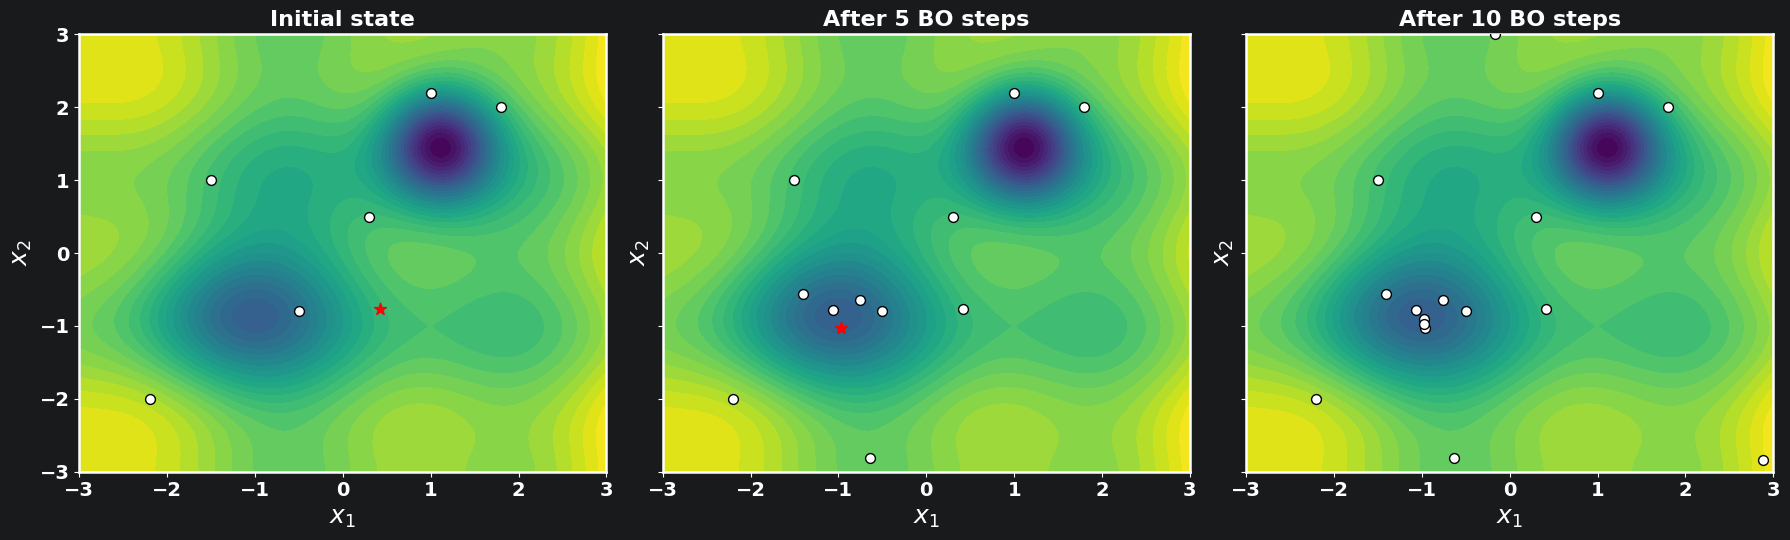

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

panel_ids_2d = [0, 5, 10]
panel_titles_2d = ["Initial state", "After 5 BO steps", "After 10 BO steps"]

for ax, idx, title in zip(axes, panel_ids_2d, panel_titles_2d):
    h = history_2d[idx]

    cont = ax.contourf(X1.numpy(), X2.numpy(), Y_grid_2d.numpy(), levels=30)
    ax.scatter(
        h["train_X"][:, 0].numpy(),
        h["train_X"][:, 1].numpy(),
        s=50,
        color="white",
        edgecolors="black",
        zorder=3,
    )
    if idx < len(history_2d) - 1:
        ax.scatter(
            h["candidate"][:, 0].numpy(),
            h["candidate"][:, 1].numpy(),
            s=80,
            marker="*",
            color="red",
            zorder=4,
        )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(r"$x_1$", fontsize=18, fontweight="bold")
    ax.set_ylabel(r"$x_2$", fontsize=18, fontweight="bold")
    style_ax(ax)

plt.tight_layout()
plt.show()

## 11. Longer-run 2D BO behaviour under a larger evaluation budget

The earlier 10-step 2D BO example was useful for visualising the **early behaviour** of the optimisation loop, but it was too short to say much about longer-run sampling behaviour.

So in this cell, we rerun the same 2D BO loop with a larger budget:

- `n_steps = 100`

and then inspect two complementary summaries:

- the **best observed value** over the full 100-step run
- and the **spatial sampling pattern** of all collected 2D points, coloured by sampling order

This should be interpreted as a **longer-run diagnostic** rather than as part of the main short-run 2D visualisation.

---

### What the code does

The first block reruns the 2D BO loop for 100 updates and stores the resulting history in `history_2d`.

It then computes:

- `best_vals_2d`, the best observed objective value at each stored BO state
- `final_X_2d`, the full final set of sampled points
- `point_order`, a simple numerical index used to colour the sampled points according to when they were collected

The resulting figure has two panels:

#### Left panel
A line plot of the best observed value over BO iterations.

This shows whether the longer-run BO process continues to improve the best value or whether it eventually plateaus.

#### Right panel
A contour map of the true 2D objective overlaid with **all sampled points**, coloured by sampling order using the `Reds` colormap.

So this panel shows not only **where** the BO loop sampled, but also **when** it sampled those locations.

That makes the temporal structure of the 2D BO trajectory much easier to read.

---

### How to read the left panel

The left panel tracks

$$
\min\bigl(y_{\text{observed}}\bigr)
$$

over the 100-step BO run.

Because this is a minimisation problem, lower values are better.

So this curve shows whether the BO loop is still discovering improved points as the evaluation budget increases.

In this particular run, the curve improves in stages rather than continuously.
That is very typical of Bayesian Optimisation.

The optimiser may spend many steps:

- refining a region,
- reducing uncertainty,
- or exploring alternatives,

before a genuinely better point is found.

So the best-value curve should not be expected to decrease smoothly at every iteration.

---

### How to read the right panel

The right panel shows all sampled points collected by the BO loop, coloured by **sampling order**.

The colourbar indicates that:

- earlier samples correspond to lower order values
- later samples correspond to higher order values

So the point colours allow the reader to reconstruct the temporal pattern of the BO process, not just the final spatial distribution.

This is especially useful in 2D, where a plain scatter plot of all sampled points can otherwise make the trajectory hard to interpret.

---

### Interpreting the acquisition behaviour

This figure reveals several characteristic behaviours of the BO loop.

#### 1. Some sampled points go to the edge of the domain

A number of points appear near the boundaries of the 2D search box.

This is not necessarily a mistake.

It happens because the BO loop is optimising the **acquisition function of the GP surrogate**, not the true objective directly.

From the perspective of the surrogate, edge regions can sometimes remain attractive because:

- they are relatively under-sampled,
- the posterior uncertainty there is still large,
- or the acquisition optimiser finds them promising under the current surrogate belief.

So boundary sampling is often a sign that the acquisition function is still assigning value to those less-certain regions.

In other words, BO is not simply “heading toward the darkest contour region” at every step.
It is balancing what looks promising with what remains uncertain.

#### 2. Some sampled points are relatively evenly spaced

The figure also shows points distributed in a fairly spread-out or approximately even way across parts of the domain.

This is also a natural BO behaviour.

When the surrogate has not yet strongly committed to one single region, the acquisition function may continue to allocate evaluations across multiple parts of the domain rather than collapsing immediately into one basin.

That can produce a sampling pattern that looks more space-filling than purely greedy.

So this even spacing is not random.
It reflects the fact that the BO loop is still learning the surface and, at certain stages, finds value in keeping coverage over different plausible regions of the domain.

---

### Why both behaviours can happen in the same run

These two behaviours:

- occasional sampling at the edges
- and broader roughly spaced-out exploration elsewhere

can coexist in the same BO run because the acquisition function is acting on a **changing surrogate**.

As the GP posterior evolves, different parts of the domain can become attractive for different reasons:

- some because they look locally promising,
- some because they are poorly constrained,
- and some because the acquisition landscape itself has multiple competing maxima.

So the sampling pattern is the result of a sequential decision process, not a fixed simple rule like “always go to the current minimum” or “always spread out uniformly.”

That is one of the main lessons of this longer-run 2D example.

---

### What this figure says about 2D BO more generally

Compared with the 1D case, the 2D BO loop has more freedom in how it allocates its evaluation budget.

That means the sampling pattern can look more complex and less obviously interpretable at first glance.

But that is exactly why this figure is valuable.

It shows that, in multidimensional BO:

- improvement does not necessarily come from a simple straight march toward one visible basin
- and the acquisition function may continue to sample a mixture of:
  - promising interior regions,
  - uncertain boundary regions,
  - and multiple competing basins

So this is a more realistic picture of how BO behaves in practice.

---

### Why this longer-run plot complements the 10-step example

The earlier 10-step figure showed the **early concentration behaviour** of the BO loop.

This 100-step figure shows the **longer-run allocation pattern** under a much larger budget.

Taken together, the two views are useful:

- the 10-step plot shows how BO begins
- the 100-step plot shows what BO looks like after the optimiser has had much more opportunity to explore and refine the search space

So this cell helps complete the multidimensional BO story.

---

### Key takeaway

This figure gives a longer-run view of the 2D BO process under a 100-step evaluation budget.

The left panel shows how the best observed value improves over time.
The right panel shows where the BO loop sampled, with the points coloured by sampling order.

The sampling pattern illustrates two realistic BO behaviours:

- some evaluations are pulled toward the **edges** because those regions remain uncertain under the surrogate
- while others are distributed in a more **spread-out** way because the acquisition function is still balancing information gathering and local refinement across the 2D domain.

---

### A note on occasional optimisation warnings

In longer 2D BO runs, it is possible to occasionally see a warning from BoTorch / SciPy during acquisition optimisation, for example a message saying that one call to `scipy.optimize.minimize` ended abnormally before BoTorch retried with a new set of initial conditions.

This does **not necessarily mean that the BO loop has failed**.

What it usually means is simply that one local optimisation attempt for the acquisition function was numerically awkward or terminated unsuccessfully from a particular starting point. Since the acquisition landscape in 2D can be non-convex and irregular, this is not unusual.

The important point is that BoTorch typically responds by **trying again with a new set of initial conditions**. So, unless the code crashes or the returned candidates become obviously unreasonable, these warnings should usually be interpreted as a sign that:

- acquisition optimisation is itself a real numerical optimisation problem,
- some restarts can fail even when the overall BO loop still succeeds,
- and the final sampled-point trajectory should still be interpreted through the surrogate–acquisition logic described above.

So if such a warning appears during this longer-run cell, it is generally best understood as a **numerical optimisation detail** rather than as evidence that the BO workflow is conceptually broken.

/Users/liangze/Desktop/PyTorch/.venv1/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


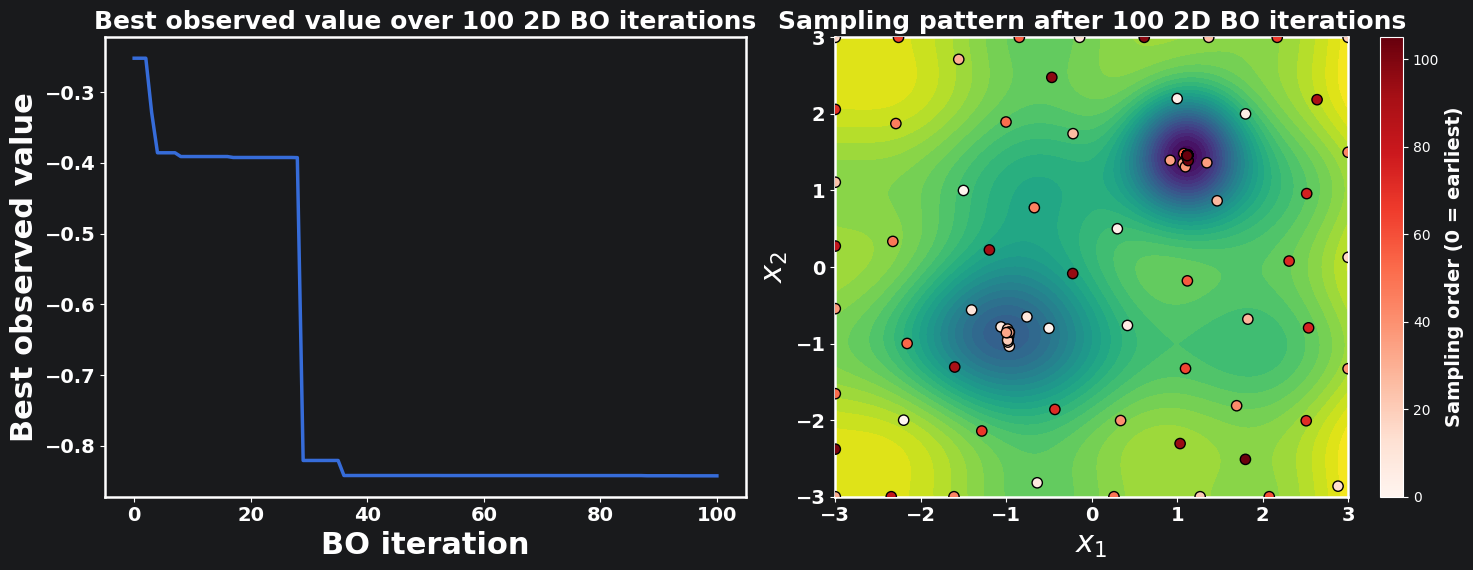

In [12]:
history_2d = run_bo_loop_2d(
    train_X_init=train_X_2d,
    train_Y_init=train_Y_2d,
    objective_fn=objective_2d,
    bounds=bounds_2d,
    n_steps=100,
)

best_vals_2d = [float(torch.min(h["train_Y"])) for h in history_2d]
final_X_2d = history_2d[-1]["train_X"]
point_order = torch.arange(final_X_2d.shape[0], dtype=torch.double)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

axes[0].plot(range(len(best_vals_2d)), best_vals_2d, linewidth=2.5)
axes[0].set_title("Best observed value over 100 2D BO iterations", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO iteration", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Best observed value", fontsize=22, fontweight="bold")
style_ax(axes[0])

cont = axes[1].contourf(X1.numpy(), X2.numpy(), Y_grid_2d.numpy(), levels=30)
sc = axes[1].scatter(
    final_X_2d[:, 0].numpy(),
    final_X_2d[:, 1].numpy(),
    c=point_order.numpy(),
    cmap="Reds",
    s=55,
    edgecolors="black",
    zorder=3,
)
axes[1].set_title("Sampling pattern after 100 2D BO iterations", fontsize=18, fontweight="bold")
axes[1].set_xlabel(r"$x_1$", fontsize=22, fontweight="bold")
axes[1].set_ylabel(r"$x_2$", fontsize=22, fontweight="bold")
style_ax(axes[1])
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("Sampling order (0 = earliest)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## 🧭 Closing Remarks

In this tutorial, we moved from **one-step acquisition-based decision making** to the **full sequential Bayesian Optimisation loop**.

The central idea was that Bayesian Optimisation is not just:

- a Gaussian Process surrogate,
- plus an acquisition function,
- plus a single candidate point.

It is a **repeated learning-and-decision process**.

At each iteration, the algorithm:

1. fits a surrogate model to the currently observed data,
2. constructs an acquisition function from that surrogate,
3. selects the next evaluation point,
4. evaluates the objective there,
5. updates the dataset,
6. and repeats.

That repeated cycle is what turns surrogate modelling and acquisition rules into a practical optimisation method.

Across the notebook, we first made this process fully interpretable in **one dimension**.

There, we saw how the BO loop gradually changes:

- the posterior mean,
- the uncertainty band,
- the sequence of selected candidate points,
- and the best observed value over time.

This made a key Bayesian Optimisation principle concrete:

> the BO loop is not directly following the true objective — it is repeatedly acting on the **current surrogate belief** about that objective.

We then extended the same BO logic to a **two-dimensional input space**.

That extension showed something important:

- the BO workflow itself does **not fundamentally change**
- but the geometry of the optimisation problem becomes richer,
- the sampling pattern becomes less obvious,
- and the optimiser may allocate evaluations in ways that are not immediately aligned with the visually deepest region of the true objective.

This is exactly how BO behaves in realistic settings.

The 2D examples made this even clearer.
The sampled-point trajectories showed that BO may:

- concentrate repeatedly in a region that looks promising under the surrogate,
- place some evaluations near the boundaries because those regions remain uncertain,
- and distribute some points more broadly when the acquisition function still sees value in exploration.

So by the end of this notebook, the full standard BO workflow is already in place:

1. define an initial dataset,
2. fit a Gaussian Process surrogate,
3. build an acquisition function,
4. optimise it to select a new point,
5. evaluate the objective,
6. update the data,
7. and repeat over multiple iterations.

The one-dimensional loop made this structure easy to interpret.
The two-dimensional extension showed that the same logic already generalises beyond toy one-dimensional settings.

That gives us a natural stopping point:

> we now know how to build and run a **standard sequential Bayesian Optimisation loop in BoTorch**.

The next stage will naturally ask how this workflow can be extended further:

- to richer BO settings,
- to more advanced acquisition behaviour,
- or to more practical optimisation scenarios beyond the standard single-loop case.